# The learned surrogate: benchmark, and where it breaks

Notebook 02 ended with two facts. The classical inversion is accurate on this
reduced physics, and it does not amortize: every shot pays the full iterative
cost over again.

A surrogate attacks the second fact. Instead of searching for the plasma once
per shot, we train a network **once** on many solved examples, and afterwards
each reconstruction is a single forward pass. The cost moves from inference
time to training time.

This notebook trains one, benchmarks it against the inversion measured in
notebook 02, and then spends most of its length on the more useful question:
**how does it fail?** A surrogate that is accurate on average and silently
wrong on the cases you care about is worse than no surrogate, because it is
trusted.

Same scope as notebook 02: reduced forward model, so both methods invert
identical physics and the comparison is fair. No Open Fusion Toolkit needed.

## Setup

In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.ml.baseline import invert_least_squares
from src.ml.dataset import (PARAM_NAMES, PARAM_RANGES, SensorLayout,
                            generate_dataset)
from src.ml.mlp import MLPRegressor, r2_score
from src.ml.uncertainty import (NOMINAL_1SIGMA, EnsembleSurrogate,
                                calibration_report, fit_variance_scaling)
from src.ml.validation import apply_dropout

layout = SensorLayout.from_config()

## Training data

The same reduced forward model from notebook 02, sampled across the physical
parameter ranges. Each row is one plasma: the 130 sensor signals it produces
are the input, the four parameters that produced them are the target.

Note the direction. In notebook 01 the parameters were the input and the
signals the output. Here it is reversed, because we are learning the inverse
map directly rather than searching for it.

In [2]:
X, y, layout = generate_dataset(n_samples=8000, noise_frac=0.02, seed=0,
                                layout=layout)

n_test = 1600
rng = np.random.default_rng(1)
perm = rng.permutation(len(X))
test_idx, train_idx = perm[:n_test], perm[n_test:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"train {X_train.shape}   test {X_test.shape}")
print(f"targets: {PARAM_NAMES}")

train (6400, 130)   test (1600, 130)
targets: ['Ip', 'R0', 'Z0', 'a']


## Train

A small fully connected network, two hidden layers of 128 units, written from
scratch in NumPy in `src/ml/mlp.py`. It standardizes inputs and targets
internally, which matters here: `Ip` is around 1e5 and `a` is around 0.1, so
without rescaling the loss would be dominated entirely by the current and the
geometry would never be learned.

trained in 5.6 s


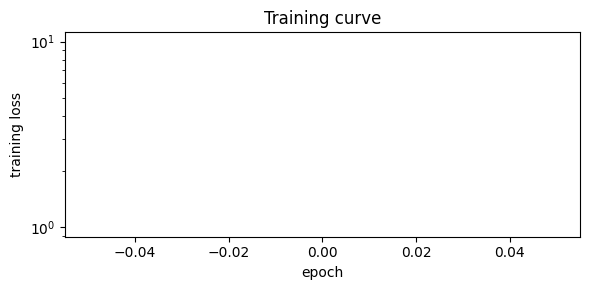

In [3]:
model = MLPRegressor(hidden_layers=(128, 128), epochs=300, seed=0)
t0 = time.perf_counter()
model.fit(X_train, y_train)
train_time = time.perf_counter() - t0

print(f"trained in {train_time:.1f} s")

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.semilogy(model.history_, lw=1.2)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("Training curve")
plt.tight_layout()
plt.show()

## Held-out accuracy

R2 is the fraction of variance explained: 1.0 is perfect, 0.0 is no better
than always predicting the mean. Evaluated on the 1600 shots the network never
saw during training.

parameter         R2           MAE   MAE/range
Ip            0.9980    2321.30608      1.01%
R0            0.9942       0.00130      1.62%
Z0            0.9933       0.00215      1.79%
a             0.9549       0.00505      3.88%


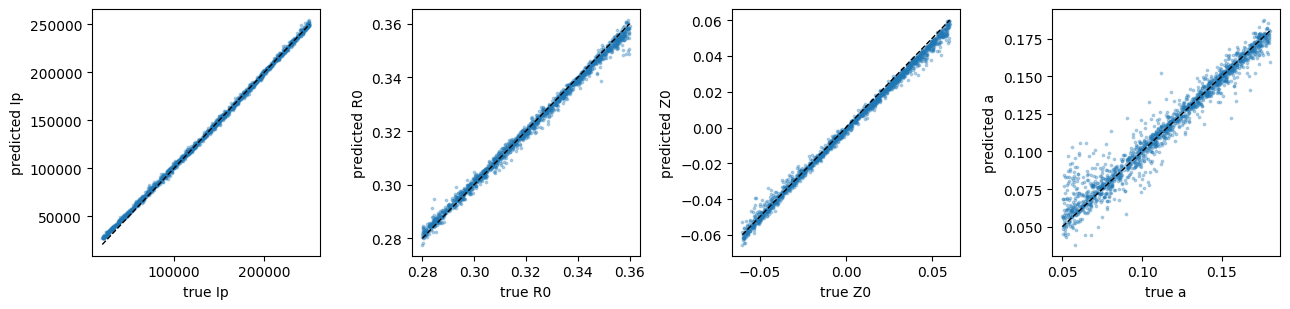

In [4]:
pred = model.predict(X_test)

print(f"{'parameter':<10}{'R2':>10}{'MAE':>14}{'MAE/range':>12}")
for j, name in enumerate(PARAM_NAMES):
    lo, hi = PARAM_RANGES[name]
    mae = np.abs(pred[:, j] - y_test[:, j]).mean()
    print(f"{name:<10}{r2_score(y_test[:, j], pred[:, j]):>10.4f}"
          f"{mae:>14.5f}{mae / (hi - lo):>11.2%}")

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for j, (ax, name) in enumerate(zip(axes, PARAM_NAMES)):
    ax.scatter(y_test[:, j], pred[:, j], s=3, alpha=0.3)
    lims = [y_test[:, j].min(), y_test[:, j].max()]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel(f"true {name}")
    ax.set_ylabel(f"predicted {name}")
plt.tight_layout()
plt.show()

Look at the `a` panel against the other three. It is visibly fatter.

That is the **same weakness the classical inversion had** in notebook 02, and
for the same physical reason: from outside the plasma, a compact current and a
slightly broader one carrying the same total current look nearly identical.
The network inherited the limitation of the measurement rather than inventing
one of its own, which is a reassuring sign. If the surrogate had been sharp on
`a` where the classical method was not, that would be evidence it had
memorized the training distribution rather than learned the physics.

## Head to head

Both methods now invert the same reduced physics from the same noisy signals,
so this is an apples-to-apples comparison. The classical inversion is slow
enough that we benchmark it on a subset.

In [5]:
n_bench = 60
Xb, yb = X_test[:n_bench], y_test[:n_bench]

t0 = time.perf_counter()
ls_pred = np.array([invert_least_squares(x, layout) for x in Xb])
ls_per_shot = (time.perf_counter() - t0) / n_bench

t0 = time.perf_counter()
nn_pred = model.predict(X_test)
nn_per_shot = (time.perf_counter() - t0) / len(X_test)

print(f"{'parameter':<10}{'R2 classical':>15}{'R2 surrogate':>15}")
for j, name in enumerate(PARAM_NAMES):
    print(f"{name:<10}{r2_score(yb[:, j], ls_pred[:, j]):>15.4f}"
          f"{r2_score(yb[:, j], nn_pred[:n_bench, j]):>15.4f}")

print(f"\nclassical  {ls_per_shot * 1e3:>10.2f} ms/shot")
print(f"surrogate  {nn_per_shot * 1e6:>10.2f} us/shot")
print(f"speedup    {ls_per_shot / nn_per_shot:>10,.0f}x")
print(f"\ntraining cost paid once: {train_time:.1f} s "
      f"(~{train_time / ls_per_shot:,.0f} classical reconstructions)")

parameter    R2 classical   R2 surrogate
Ip                 0.9999         0.9979
R0                 0.9947         0.9960
Z0                 0.9991         0.9947
a                  0.9651         0.9685

classical       14.06 ms/shot
surrogate        0.86 us/shot
speedup        16,303x

training cost paid once: 5.6 s (~396 classical reconstructions)


### What the speedup does and does not mean

It is a real number and it is also easy to oversell, so state it carefully.

**What it means.** Once trained, reconstruction is amortized. The break-even
point is printed above: the training cost is repaid after roughly that many
shots, and everything past it is free by comparison. That is what makes
parameter scans, uncertainty studies over many samples, or anything inside a
control or design loop practical.

**What it does not mean.** It is not "faster than reconstructing a real
plasma". Both sides invert the *reduced* model. A real Grad-Shafranov
reconstruction is a much heavier calculation, so the honest comparison there
would be against something far slower, and the surrogate would need to be
trained on real solves to make that claim. `data/gs_dataset.npz` holds 2000 of
those; using them is the documented next step, not something this notebook
claims.

The number is quoted in the README with the same caveat attached. Any speedup
figure without its baseline stated is marketing.

## Failure mode 1: sensors die

Magnetic probes fail. A reconstruction method that assumes all 130 channels
are healthy will quietly degrade when they are not, and the whole point of
this section is to find out how quickly.

`apply_dropout` mean-imputes a random fraction of channels per shot, which
models independent probe failures across a run.

  dropout   R2 baseline   R2 augmented
      0%        0.9851         0.9108
      5%        0.8613         0.9307
     10%        0.7872         0.9514
     20%        0.6758         0.9561


     30%        0.5725         0.9019


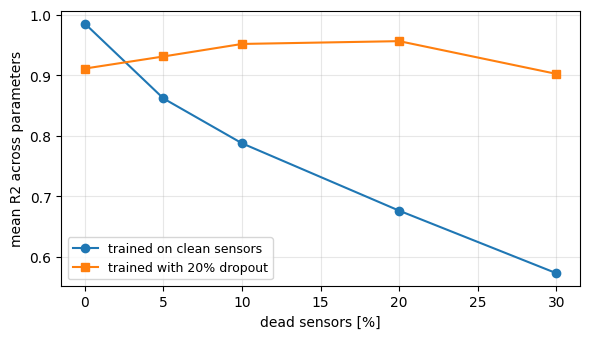

In [6]:
model_robust = MLPRegressor(hidden_layers=(128, 128), epochs=300, seed=0,
                            input_dropout=0.2)
model_robust.fit(X_train, y_train)

def mean_r2(m, frac, seed):
    Xd = apply_dropout(X_test, m, frac, np.random.default_rng(seed))
    p = m.predict(Xd)
    return np.mean([r2_score(y_test[:, j], p[:, j])
                    for j in range(len(PARAM_NAMES))])

# Averaged over several dropout draws so the curve reflects the models rather
# than one unlucky choice of which channels died.
fracs = [0.0, 0.05, 0.10, 0.20, 0.30]
seeds = range(3)

print(f"{'dropout':>9}{'R2 baseline':>14}{'R2 augmented':>15}")
rows = []
for f in fracs:
    r2_base = np.mean([mean_r2(model, f, s) for s in seeds])
    r2_rob = np.mean([mean_r2(model_robust, f, s) for s in seeds])
    rows.append((f, r2_base, r2_rob))
    print(f"{f:>8.0%}{r2_base:>14.4f}{r2_rob:>15.4f}")

rows = np.array(rows)
fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))
ax.plot(rows[:, 0] * 100, rows[:, 1], "o-", label="trained on clean sensors")
ax.plot(rows[:, 0] * 100, rows[:, 2], "s-", label="trained with 20% dropout")
ax.set_xlabel("dead sensors [%]")
ax.set_ylabel("mean R2 across parameters")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### The tradeoff, stated plainly

Robustness to sensor loss is not a feature bolted on afterwards. It is a
consequence of **what the network was trained on**. The augmented model sees
dead channels during training, so it learns to reconstruct without them. The
baseline model falls off a cliff; the augmented one does not.

And it is a genuine trade, not a free win. At zero dropout the augmented model
is clearly *worse* than the baseline, so you pay for the robustness in
accuracy when the diagnostics are healthy.

### An oddity in that table worth not skipping past

Look along the augmented row. It does not decrease monotonically. Accuracy
*rises* from 0% dropout to a peak near 20%, and only then falls.

That looks like a bug and it is not. It reproduces across independent dropout
draws with a spread of a few parts in a thousand, so it is a property of the
model rather than luck. The explanation is that `input_dropout=0.2` zeroes
about 20% of channels **on every training batch**, which means this network was
*never shown a fully healthy sensor set during training*. Clean input is
therefore itself a distribution shift for it, and its accuracy peaks at roughly
the dropout rate it was trained at.

The general lesson is worth more than the specific curve: a model is most
accurate on the distribution it was trained on, and "clean data" is not
automatically the easiest case. If you deploy the augmented model on a fully
healthy diagnostic set, you are using it out of distribution.

Which model to ship therefore depends on how reliable the real diagnostics
are, and that is not yet known for CUTE. Both are in `models/`, and the README
says why.

## Failure mode 2: a number with no error bar

Everything above reports a single best guess. That is not enough to act on. A
reconstruction of `Ip = 148 kA` means something very different if the model is
confident to 1 kA than if it could be off by 20 kA, and nothing so far
distinguishes those cases.

A **deep ensemble** gives one handle on this: train several networks that
differ in their initialization and their data draw, and use their disagreement
as an uncertainty estimate. Where they agree, the answer is probably well
determined by the signals. Where they scatter, it is not.

The catch is that raw disagreement is **not** automatically a calibrated error
bar, and assuming it is would be exactly the kind of unverified claim this
project tries to avoid. So we measure it.

In [7]:
members = []
for k in range(5):
    Xk, yk, _ = generate_dataset(n_samples=6000, noise_frac=0.02,
                                 seed=100 * (k + 1), layout=layout)
    m = MLPRegressor(hidden_layers=(128, 128), epochs=250, seed=k)
    m.fit(Xk, yk)
    members.append(m)
ensemble = EnsembleSurrogate(models=members)

# Two DISJOINT splits: one to fit the calibration, one to report it. Fitting
# and reporting on the same data would be circular and would always look good.
half = n_test // 2
X_cal, y_cal = X_test[:half], y_test[:half]
X_rep, y_rep = X_test[half:], y_test[half:]

mu_cal, sd_cal = ensemble.predict_with_std(X_cal)
mu_rep, sd_rep = ensemble.predict_with_std(X_rep)

raw = calibration_report(y_rep, mu_rep, sd_rep)
scales = fit_variance_scaling(y_cal, mu_cal, sd_cal)
cal = calibration_report(y_rep, mu_rep, sd_rep * scales)

print(f"nominal 1-sigma coverage = {NOMINAL_1SIGMA:.3f}\n")
print(f"{'parameter':<10}{'raw cov':>10}{'scale':>9}{'calibrated cov':>17}")
for j, name in enumerate(PARAM_NAMES):
    print(f"{name:<10}{raw.coverage_1sigma[name]:>10.3f}"
          f"{scales[j]:>9.2f}{cal.coverage_1sigma[name]:>17.3f}")

nominal 1-sigma coverage = 0.683

parameter    raw cov    scale   calibrated cov
Ip             0.939     0.44            0.682
R0             0.795     0.68            0.620
Z0             0.880     0.57            0.691
a              0.595     1.30            0.693


### Read the middle column

Those scale factors are the finding. A value near 1.0 would mean the raw
ensemble spread was already an honest error bar. Values far from 1.0 mean it
was not: below 1.0 the ensemble was over-cautious, above 1.0 it was
overconfident, which is the dangerous direction.

The fix is deliberately unglamorous. For each parameter, take the empirical
distribution of `|error| / sigma` on the calibration split and read off the
quantile at the coverage level you want. Multiplying sigma by that factor makes
coverage match nominal by construction. It is nonparametric, so it assumes
nothing about the error distribution being Gaussian.

Two things that make it honest rather than circular:

- The scale factors are fit on `X_cal` and reported on `X_rep`, which share no
  shots. Fitting and reporting on the same data would guarantee a good number
  and mean nothing.
- Coverage is compared against the nominal 0.683, not against a target chosen
  after seeing the result.

The calibrated numbers land near nominal but not exactly on it, and one
parameter can come out noticeably short. That is expected and is the honest
outcome: the scale factors are fitted on a finite calibration split and then
applied to different shots, so they transfer imperfectly. A procedure that
produced exactly 0.683 on held-out data every time would be a sign that
something had leaked between the two splits.

This calibration step is the part of the project with the fewest competitors.
Plenty of published surrogates report R2. Far fewer check whether their error
bars are true.

## What is deliberately not claimed here

Worth being explicit, since this is where a reader should push back.

1. **The physics is reduced.** Rigid current disk, no free-boundary solve.
   Every number in this notebook inherits that.
2. **The noise model is invented.** 2% independent Gaussian per channel. Real
   magnetics may be correlated, drifting or spiky. If they are, the calibrated
   error bars stop meaning what they say, because calibration is only valid
   for the noise distribution it was fitted under.
3. **The parameter ranges are assumed.** They are physically plausible for a
   CUTE-scale spherical tokamak, but nothing here establishes that real CUTE
   discharges fall inside them. A surrogate asked about a plasma outside its
   training distribution can be confidently wrong, and the ensemble spread is
   not guaranteed to catch it.

Points 2 and 3 are the same critique Chris Hansen raised: *where does your
equilibria map lie relative to that noise distribution?* Both are blocked on
seeing real measurements, and both are documented rather than papered over.

## The next step, which this notebook does not take

`data/gs_dataset.npz` already contains 2000 genuine Grad-Shafranov equilibria
solved with TokaMaker, each with its 130 diagnostic signals and its own
measured parameters. Training on that replaces caveat 1 above with real
physics.

In [8]:
gs_path = os.path.join(REPO_ROOT, "data", "gs_dataset.npz")
if os.path.exists(gs_path):
    gs = np.load(gs_path, allow_pickle=True)
    print(f"source: {gs['source']}")
    for k in ("X", "y", "extras", "psi"):
        print(f"  {k:<8} {str(gs[k].shape):<16}")
    print(f"  targets available beyond [Ip, R0, Z0, a]: "
          f"{list(gs['extra_names'])}")
else:
    print("data/gs_dataset.npz not present (gitignored, 170 MB).")
    print("Regenerate with: python scripts/generate_gs_dataset.py --samples 2000")

source: tokamaker_grad_shafranov
  X        (2000, 130)     
  y        (2000, 4)       
  extras   (2000, 7)       


  psi      (2000, 23079)   
  targets available beyond [Ip, R0, Z0, a]: [np.str_('kappa'), np.str_('delta'), np.str_('q_95'), np.str_('beta_pol'), np.str_('l_i'), np.str_('vol'), np.str_('W_MHD')]


Two differences matter when that swap happens.

**The labels get better.** They come from `get_stats()` on each solved
equilibrium, so they describe the plasma that actually exists rather than the
one that was requested. Notebook 00 measured how far apart those two can be.

**The benchmark gets harder to state.** There is no cheap classical inversion
of the Grad-Shafranov model to compare against, because inverting it means
running TokaMaker inside the optimizer loop, which is the cost that motivated
all of this in the first place. So the comparison changes shape, and the
speedup claim has to be rewritten rather than reused.

That is the honest end of this sequence: the pipeline works, its limits are
measured, and the next step is written down along with what it will cost.